# Customer Churn Analysis and Prediction

**Telecommunications Company - Churn Study**

This notebook covers four of the six project tasks:

1. **Task 1 - Data Preparation**
2. **Task 2 - Exploratory Data Analysis (EDA)**
3. **Task 4 - Churn Prediction Model**
4. **Task 5 - Model Evaluation and Interpretation**

---

## 1. Introduction

Customer churn - the loss of subscribers - is one of the most expensive problems a telecom company
faces: acquiring a new customer typically costs far more than retaining an existing one. This project
analyzes a telecom customer dataset to understand **why** customers leave and to build a **predictive
model** that flags at-risk customers before they churn, so retention efforts can be targeted where
they matter most.

## 2. Dataset Description

The dataset (`telco_churn.csv`) contains one row per customer with the following types of fields:

| Category | Columns |
|---|---|
| **Identifier** | `customerID` |
| **Demographics** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Account info** | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` |
| **Services subscribed** | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Target** | `Churn` (Yes / No) |

---
# TASK 1: DATA PREPARATION
### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

COLOR_YES = '#E24A33'   # churned
COLOR_NO  = '#348ABD'   # retained

### Load Dataset

In [ ]:
df = pd.read_csv('telco_churn.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Overview

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Values

`TotalCharges` is loaded as an `object` dtype because a small number of brand-new customers
(`tenure == 0`) have blank strings instead of a numeric value. We convert it to numeric first, which
turns those blanks into `NaN` so they can be counted and handled properly.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing if len(missing) else "None")

df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Columns with missing values:
TotalCharges    11
dtype: int64


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [ ]:
# These are all new customers (tenure = 0), so TotalCharges should reasonably be 0
df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = 0
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### Data Cleaning

In [ ]:
# Drop the identifier column - it carries no predictive signal
df.drop(columns=['customerID'], inplace=True)

# Standardize the "No internet service" / "No phone service" labels to "No" for the
# add-on service columns, since they are functionally equivalent to not having the service
no_service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
for c in no_service_cols:
    df[c] = df[c].replace({'No internet service': 'No'})
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("Duplicate rows:", df.duplicated().sum())
df.head()

Duplicate rows: 22


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Encoding

- Binary categorical columns (Yes/No, Male/Female) → label-encoded to 0/1.
- Multi-category columns (`Contract`, `PaymentMethod`, `InternetService`) → one-hot encoded, since
  they have no ordinal relationship.
- A clean, human-readable copy (`df`) is kept for the EDA section; the encoded copy (`df_model`) is
  used for modeling later in Task 4.

In [ ]:
df_model = df.copy()

binary_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])
    # Churn: No -> 0, Yes -> 1 ; verify mapping
print("Churn encoding check:", dict(zip(le.classes_, le.transform(le.classes_))) if col == 'Churn' else '')

multi_cat_cols = ['InternetService', 'Contract', 'PaymentMethod']
df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=False)

# Make sure one-hot columns are ints, not bools
ohe_cols = [c for c in df_model.columns if c.split('_')[0] in ['InternetService', 'Contract', 'PaymentMethod']]
df_model[ohe_cols] = df_model[ohe_cols].astype(int)

print(f"Encoded dataset shape: {df_model.shape}")
df_model.head()

Churn encoding check: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded dataset shape: (7043, 27)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,0,1,0,1,0,0,0,0,1,0


### Train/Test Split

In [ ]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Churn rate - train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}")

Training set: 5634 rows
Test set:     1409 rows
Churn rate - train: 26.54%  |  test: 26.54%


---
# TASK 2: EXPLORATORY DATA ANALYSIS
### Overall Churn Rate

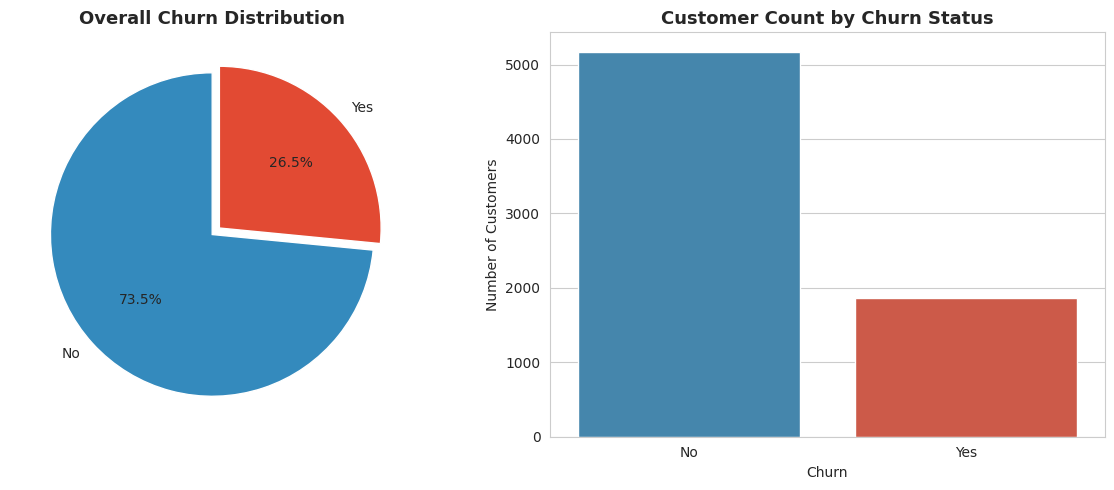

Overall churn rate: 26.54%
(1869 of 7043 customers have churned)


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_rate = (df['Churn'] == 'Yes').mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=[COLOR_NO, COLOR_YES], startangle=90, explode=(0, 0.06))
axes[0].set_title('Overall Churn Distribution')

sns.countplot(data=df, x='Churn', hue='Churn', palette=[COLOR_NO, COLOR_YES],
              order=['No', 'Yes'], legend=False, ax=axes[1])
axes[1].set_title('Customer Count by Churn Status')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print(f"Overall churn rate: {churn_rate:.2%}")
print(f"({churn_counts['Yes']} of {len(df)} customers have churned)")

### Gender Analysis

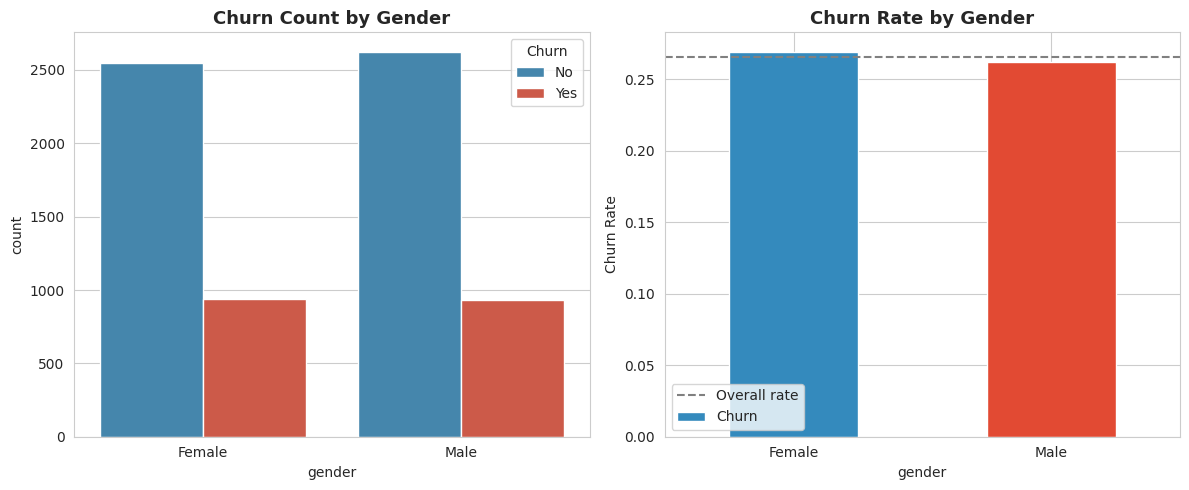

gender
Female    26.9%
Male      26.2%
Name: Churn, dtype: str


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='gender', hue='Churn', palette=[COLOR_NO, COLOR_YES], ax=axes[0])
axes[0].set_title('Churn Count by Gender')

gender_churn = df.groupby('gender')['Churn'].apply(lambda s: (s == 'Yes').mean())
gender_churn.plot(kind='bar', color=[COLOR_NO, COLOR_YES], ax=axes[1], rot=0)
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(churn_rate, color='gray', linestyle='--', label='Overall rate')
axes[1].legend()

plt.tight_layout()
plt.show()
print(gender_churn.apply(lambda x: f"{x:.1%}"))

### Partner Analysis

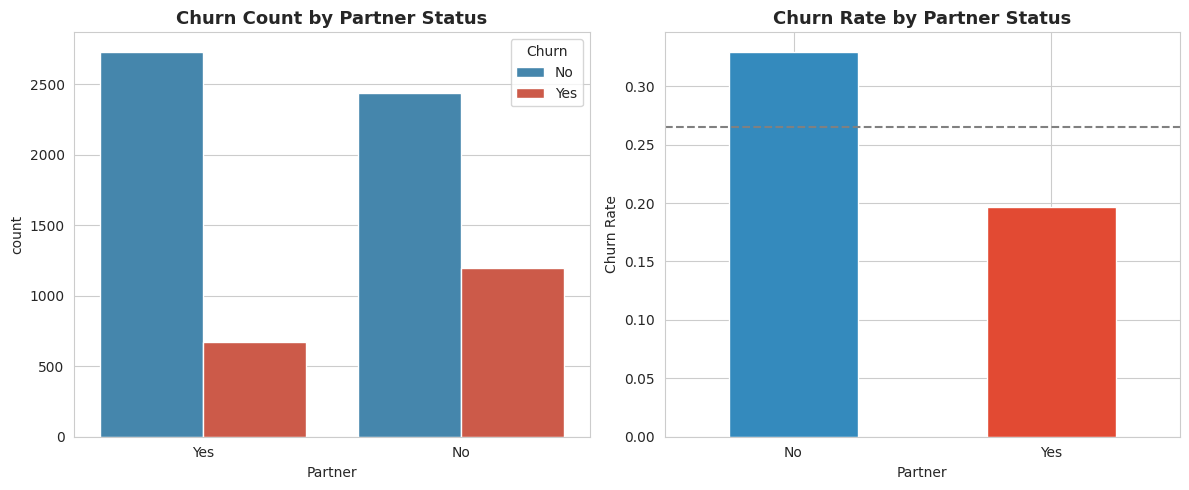

Partner
No     33.0%
Yes    19.7%
Name: Churn, dtype: str


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Partner', hue='Churn', palette=[COLOR_NO, COLOR_YES], ax=axes[0])
axes[0].set_title('Churn Count by Partner Status')

partner_churn = df.groupby('Partner')['Churn'].apply(lambda s: (s == 'Yes').mean())
partner_churn.plot(kind='bar', color=[COLOR_NO, COLOR_YES], ax=axes[1], rot=0)
axes[1].set_title('Churn Rate by Partner Status')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(churn_rate, color='gray', linestyle='--')

plt.tight_layout()
plt.show()
print(partner_churn.apply(lambda x: f"{x:.1%}"))

### Dependents Analysis

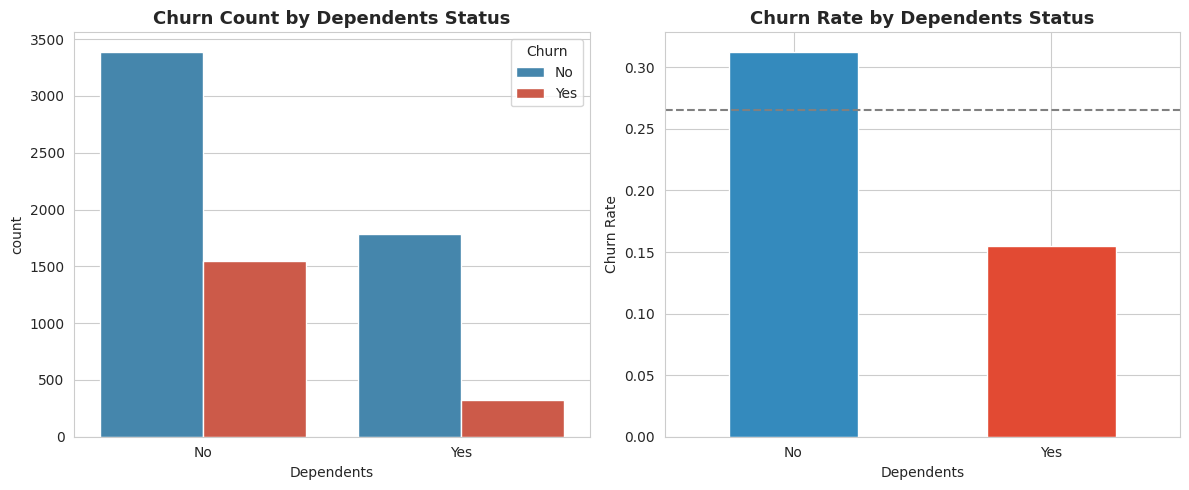

Dependents
No     31.3%
Yes    15.5%
Name: Churn, dtype: str


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Dependents', hue='Churn', palette=[COLOR_NO, COLOR_YES], ax=axes[0])
axes[0].set_title('Churn Count by Dependents Status')

dep_churn = df.groupby('Dependents')['Churn'].apply(lambda s: (s == 'Yes').mean())
dep_churn.plot(kind='bar', color=[COLOR_NO, COLOR_YES], ax=axes[1], rot=0)
axes[1].set_title('Churn Rate by Dependents Status')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(churn_rate, color='gray', linestyle='--')

plt.tight_layout()
plt.show()
print(dep_churn.apply(lambda x: f"{x:.1%}"))

### Tenure Analysis

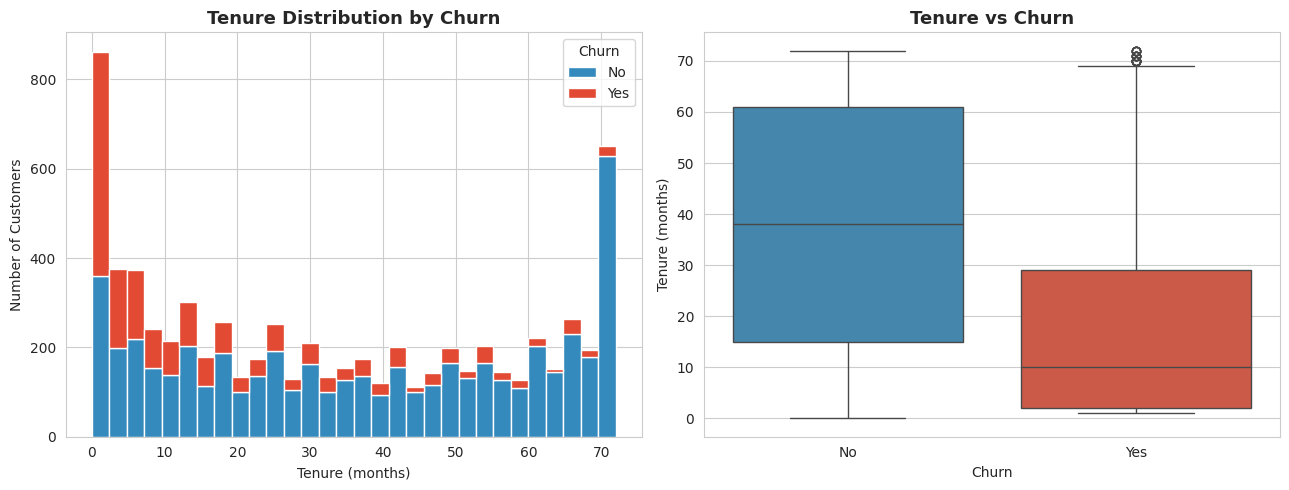

            mean   50%        std
Churn                            
No     37.569965  38.0  24.113777
Yes    17.979133  10.0  19.531123


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist([df.loc[df['Churn'] == 'No', 'tenure'], df.loc[df['Churn'] == 'Yes', 'tenure']],
             bins=30, stacked=True, color=[COLOR_NO, COLOR_YES], label=['No', 'Yes'])
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn')

sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', order=['No', 'Yes'],
            palette=[COLOR_NO, COLOR_YES], legend=False, ax=axes[1])
axes[1].set_title('Tenure vs Churn')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.show()

print(df.groupby('Churn')['tenure'].describe()[['mean', '50%', 'std']])

### Contract Analysis

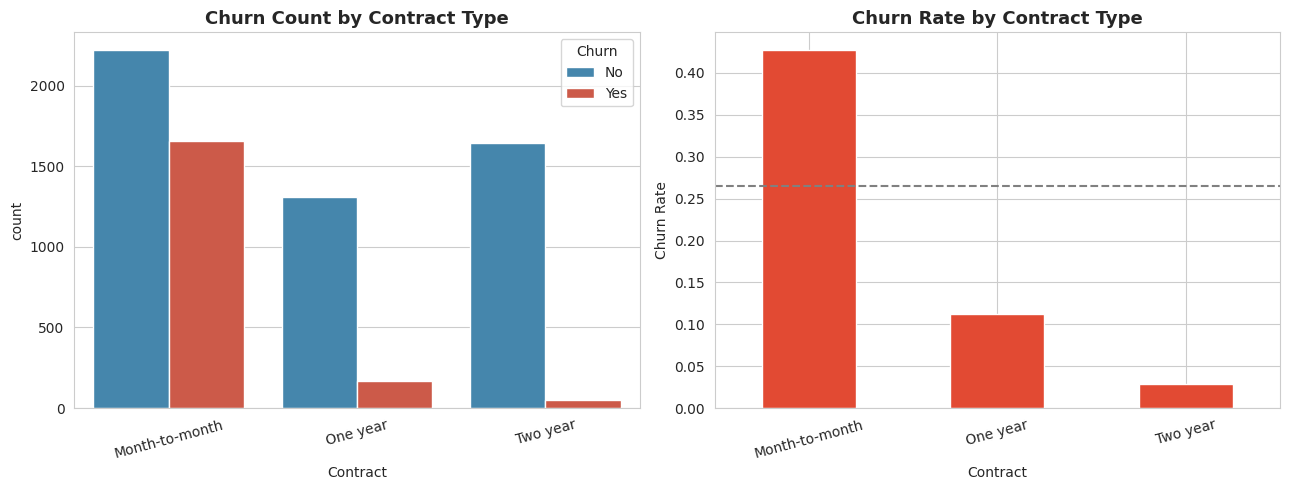

Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: str


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Contract', hue='Churn', palette=[COLOR_NO, COLOR_YES],
              order=['Month-to-month', 'One year', 'Two year'], ax=axes[0])
axes[0].set_title('Churn Count by Contract Type')
axes[0].tick_params(axis='x', rotation=15)

contract_churn = df.groupby('Contract')['Churn'].apply(lambda s: (s == 'Yes').mean())
contract_churn = contract_churn.reindex(['Month-to-month', 'One year', 'Two year'])
contract_churn.plot(kind='bar', color=COLOR_YES, ax=axes[1], rot=15)
axes[1].set_title('Churn Rate by Contract Type')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(churn_rate, color='gray', linestyle='--')

plt.tight_layout()
plt.show()
print(contract_churn.apply(lambda x: f"{x:.1%}"))

### Payment Method Analysis

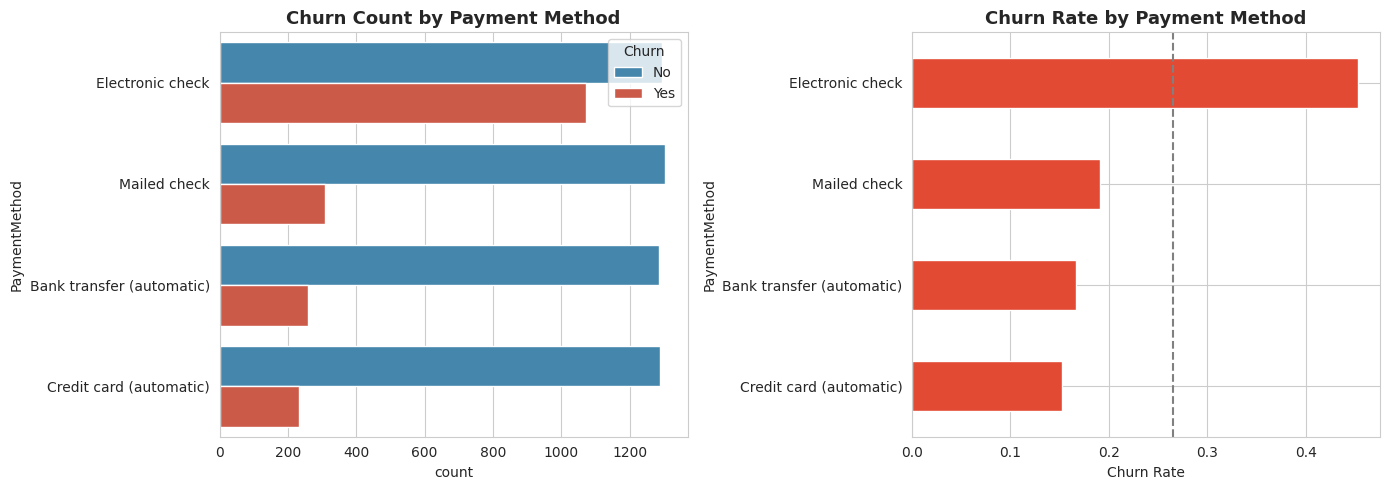

PaymentMethod
Credit card (automatic)      15.2%
Bank transfer (automatic)    16.7%
Mailed check                 19.1%
Electronic check             45.3%
Name: Churn, dtype: str


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, y='PaymentMethod', hue='Churn', palette=[COLOR_NO, COLOR_YES], ax=axes[0])
axes[0].set_title('Churn Count by Payment Method')

pm_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda s: (s == 'Yes').mean()).sort_values()
pm_churn.plot(kind='barh', color=COLOR_YES, ax=axes[1])
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_xlabel('Churn Rate')
axes[1].axvline(churn_rate, color='gray', linestyle='--')

plt.tight_layout()
plt.show()
print(pm_churn.apply(lambda x: f"{x:.1%}"))

### Monthly Charges Analysis

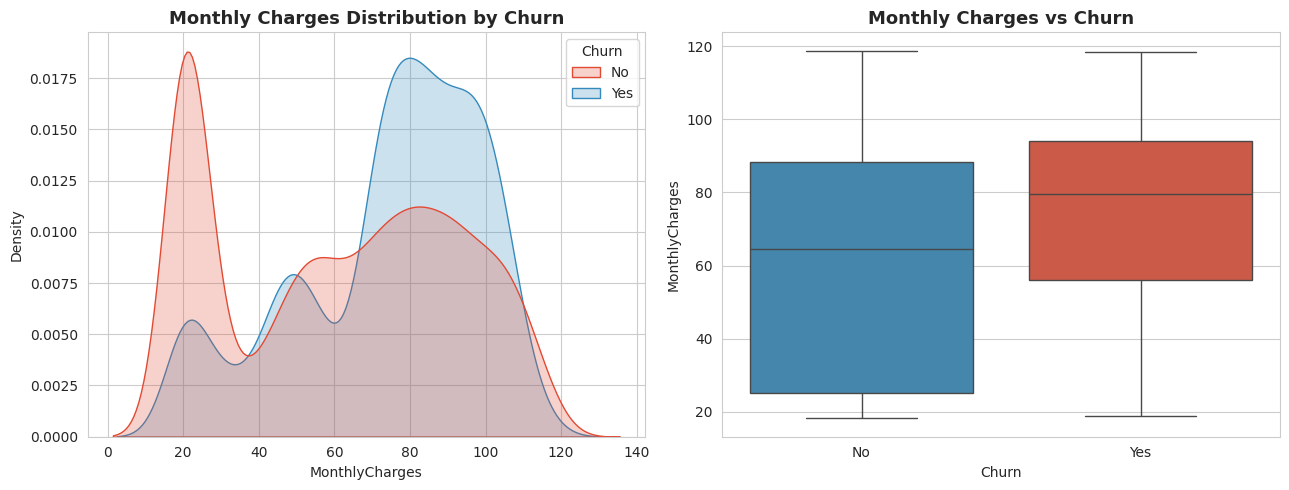

            mean     50%        std
Churn                              
No     61.265124  64.425  31.092648
Yes    74.441332  79.650  24.666053


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True,
            palette=[COLOR_YES, COLOR_NO], common_norm=False, ax=axes[0])
axes[0].set_title('Monthly Charges Distribution by Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', order=['No', 'Yes'],
            palette=[COLOR_NO, COLOR_YES], legend=False, ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].describe()[['mean', '50%', 'std']])

### EDA Summary

- The dataset has a **churn rate around 26–27%** - a meaningful but manageable class imbalance.
- **Gender** shows almost no relationship with churn.
- Customers **without a partner or without dependents** churn noticeably more than those with.
- **Tenure** is strongly related to churn: customers who churn have a much lower median tenure -
  churn risk is highest in the first few months and drops off the longer someone stays.
- **Contract type** is one of the strongest churn drivers: month-to-month customers churn far more
  than one-year or two-year contract holders.
- **Electronic check** payers churn at a noticeably higher rate than customers on automatic payment
  methods (bank transfer / credit card).
- Customers with **higher monthly charges** tend to churn more than those with lower charges.

---
# TASK 4: CHURN PREDICTION
### Preprocessing Pipeline

We reuse the encoded dataset (`df_model`) and train/test split from Task 1. Tree-based models don't
need feature scaling, but Logistic Regression does - so we scale a copy of the numeric features for
that model only.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

results = {}  # collects metrics for every model we try

### Logistic Regression

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
pred_lr = log_reg.predict(X_test_scaled)

results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, pred_lr),
    'Precision': precision_score(y_test, pred_lr),
    'Recall': recall_score(y_test, pred_lr),
    'F1-score': f1_score(y_test, pred_lr),
}
print(classification_report(y_test, pred_lr, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42, max_depth=6)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, pred_dt),
    'Precision': precision_score(y_test, pred_dt),
    'Recall': recall_score(y_test, pred_dt),
    'F1-score': f1_score(y_test, pred_dt),
}
print(classification_report(y_test, pred_dt, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.66      0.49      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



### Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, pred_rf),
    'Precision': precision_score(y_test, pred_rf),
    'Recall': recall_score(y_test, pred_rf),
    'F1-score': f1_score(y_test, pred_rf),
}
print(classification_report(y_test, pred_rf, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



### Model Comparison

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.804,0.654,0.556,0.601
Random Forest,0.793,0.635,0.516,0.569
Decision Tree,0.798,0.662,0.487,0.561


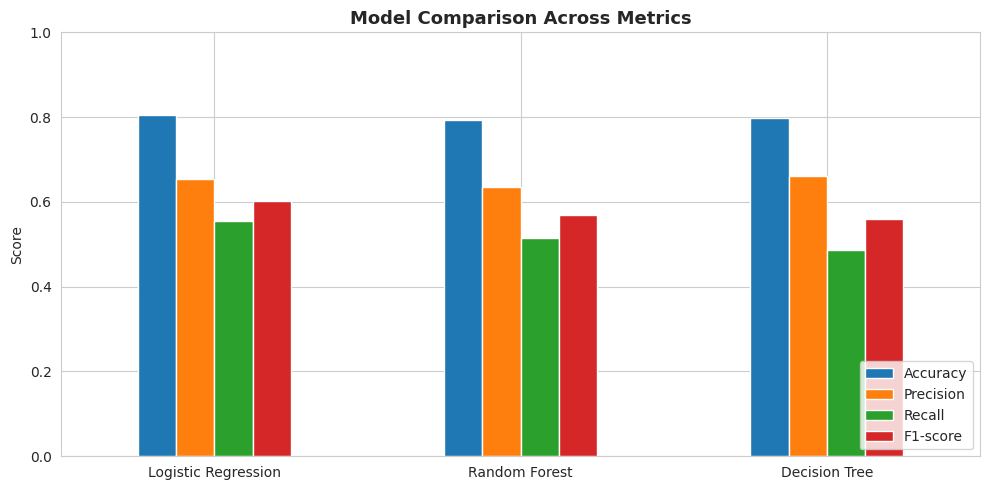

In [ ]:
results_df = pd.DataFrame(results).T.sort_values('F1-score', ascending=False)
display(results_df.style.format('{:.3f}').background_gradient(cmap='Blues'))

results_df.plot(kind='bar', figsize=(10, 5), rot=0)
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Feature Selection

We use the Random Forest's built-in feature importances to identify the variables carrying the most
predictive signal, and refit a model on a reduced feature set to check we don't lose meaningful
performance.

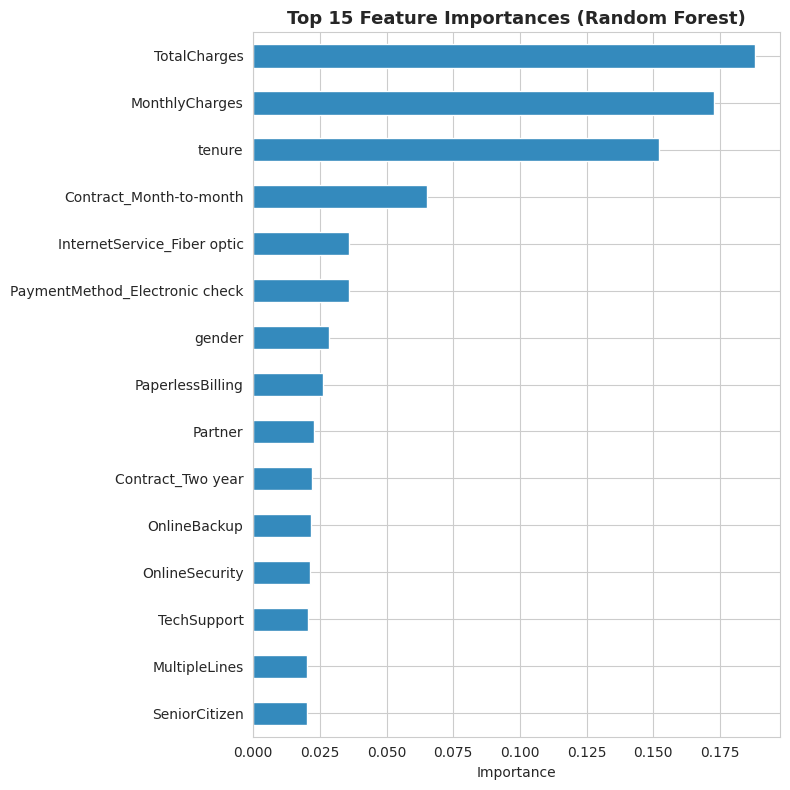

Selected top features:
['TotalCharges', 'MonthlyCharges', 'tenure', 'Contract_Month-to-month', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'gender', 'PaperlessBilling', 'Partner', 'Contract_Two year', 'OnlineBackup', 'OnlineSecurity']


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).sort_values().plot(kind='barh', color='#348ABD')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_features = importances.head(12).index.tolist()
print("Selected top features:")
print(top_features)

In [ ]:
# Refit Random Forest on the reduced feature set to confirm performance holds up
rf_reduced = RandomForestClassifier(n_estimators=300, random_state=42)
rf_reduced.fit(X_train[top_features], y_train)
pred_rf_reduced = rf_reduced.predict(X_test[top_features])

print(f"Full-feature F1:    {results['Random Forest']['F1-score']:.3f}")
print(f"Reduced-feature F1: {f1_score(y_test, pred_rf_reduced):.3f}")

Full-feature F1:    0.569
Reduced-feature F1: 0.545


### Hyperparameter Tuning

We tune the Random Forest - the strongest model so far - with `GridSearchCV` using 5-fold
cross-validation, optimizing for F1-score (a balance of precision and recall, which matters more than
raw accuracy for an imbalanced churn problem).

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV F1-score: {grid_search.best_score_:.3f}")

best_rf = grid_search.best_estimator_
pred_best = best_rf.predict(X_test)

results['Random Forest (Tuned)'] = {
    'Accuracy': accuracy_score(y_test, pred_best),
    'Precision': precision_score(y_test, pred_best),
    'Recall': recall_score(y_test, pred_best),
    'F1-score': f1_score(y_test, pred_best),
}

results_df = pd.DataFrame(results).T.sort_values('F1-score', ascending=False)
display(results_df.style.format('{:.3f}').background_gradient(cmap='Blues'))

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-score: 0.568


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.804,0.654,0.556,0.601
Random Forest (Tuned),0.798,0.646,0.527,0.580
Random Forest,0.793,0.635,0.516,0.569
Decision Tree,0.798,0.662,0.487,0.561


---
# TASK 5: MODEL EVALUATION
### Best Model

We select the model with the highest F1-score on the held-out test set as our final model,
since F1 balances precision (avoiding wasted retention offers) and recall (catching churners we
can't afford to miss).

In [ ]:
best_model_name = results_df['F1-score'].idxmax()
print(f"Best model: {best_model_name}")

model_map = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Decision Tree': (dt, X_test),
    'Random Forest': (rf, X_test),
    'Random Forest (Tuned)': (best_rf, X_test),
}
final_model, final_X_test = model_map[best_model_name]
final_pred = final_model.predict(final_X_test)
final_proba = final_model.predict_proba(final_X_test)[:, 1]

Best model: Logistic Regression


### Confusion Matrix

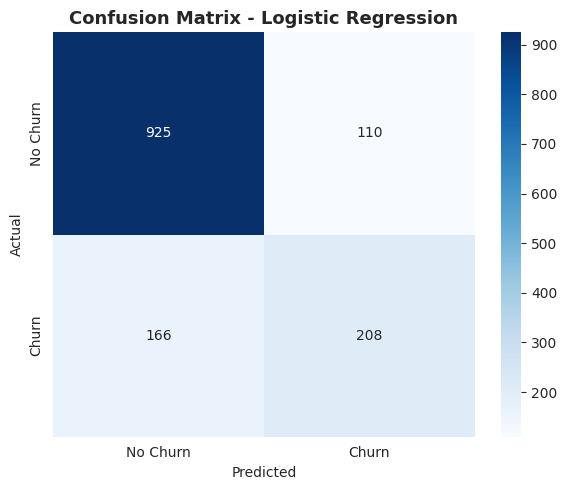

True Negatives:  925   False Positives: 110
False Negatives: 166   True Positives:  208


In [ ]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}   False Positives: {fp}")
print(f"False Negatives: {fn}   True Positives:  {tp}")

### Accuracy, Precision, Recall, F1 Score

Accuracy     0.804
Precision    0.654
Recall       0.556
F1-score     0.601
dtype: str


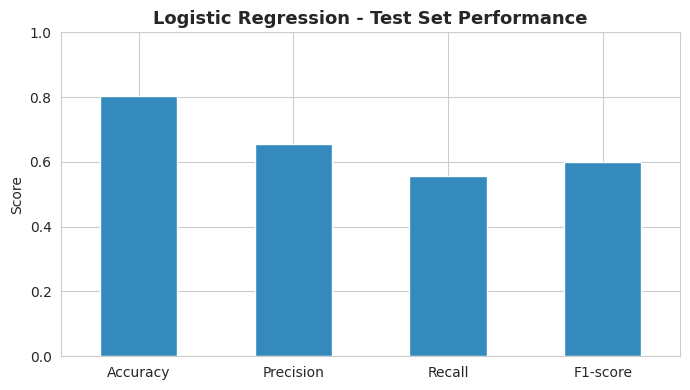

Accuracy  (80.4%): overall share of customers correctly classified.
Precision (65.4%): of customers predicted to churn, how many actually did - matters for avoiding wasted retention offers.
Recall    (55.6%): of customers who actually churned, how many we caught - matters for not missing at-risk customers.
F1-score  (60.1%): harmonic mean of precision and recall, our primary selection metric.


In [ ]:
acc = accuracy_score(y_test, final_pred)
prec = precision_score(y_test, final_pred)
rec = recall_score(y_test, final_pred)
f1 = f1_score(y_test, final_pred)

metrics_summary = pd.Series({'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1})
print(metrics_summary.apply(lambda x: f"{x:.3f}"))

metrics_summary.plot(kind='bar', color='#348ABD', rot=0, figsize=(7, 4))
plt.ylim(0, 1)
plt.title(f'{best_model_name} - Test Set Performance')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

summary_text = (
    f"Accuracy  ({acc:.1%}): overall share of customers correctly classified.\n"
    f"Precision ({prec:.1%}): of customers predicted to churn, how many actually did - matters for avoiding wasted retention offers.\n"
    f"Recall    ({rec:.1%}): of customers who actually churned, how many we caught - matters for not missing at-risk customers.\n"
    f"F1-score  ({f1:.1%}): harmonic mean of precision and recall, our primary selection metric."
)
print(summary_text)

### ROC Curve

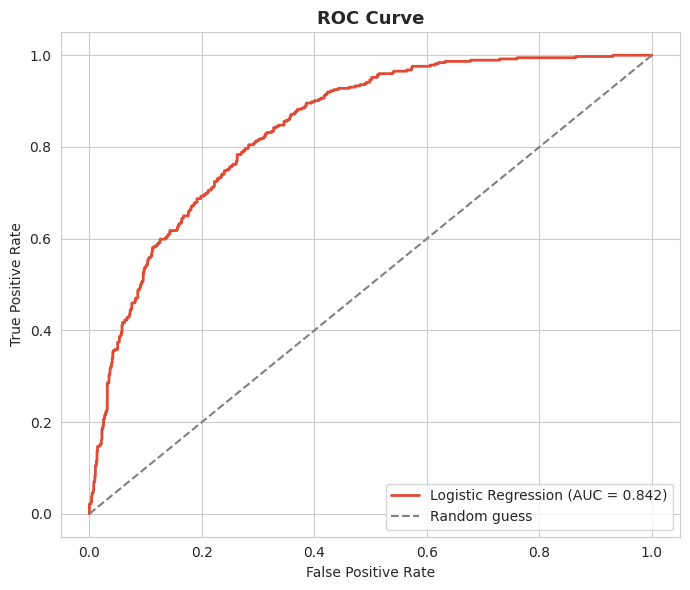

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, final_proba)
auc_score = roc_auc_score(y_test, final_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color=COLOR_YES, lw=2, label=f'{best_model_name} (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### AUC

In [ ]:
print(f"AUC (Area Under the ROC Curve): {auc_score:.3f}")
if auc_score >= 0.9:
    verdict = "excellent"
elif auc_score >= 0.8:
    verdict = "good"
elif auc_score >= 0.7:
    verdict = "acceptable"
else:
    verdict = "weak"
print(f"This indicates {verdict} ability to distinguish churners from non-churners.")

AUC (Area Under the ROC Curve): 0.842
This indicates good ability to distinguish churners from non-churners.


### Feature Importance

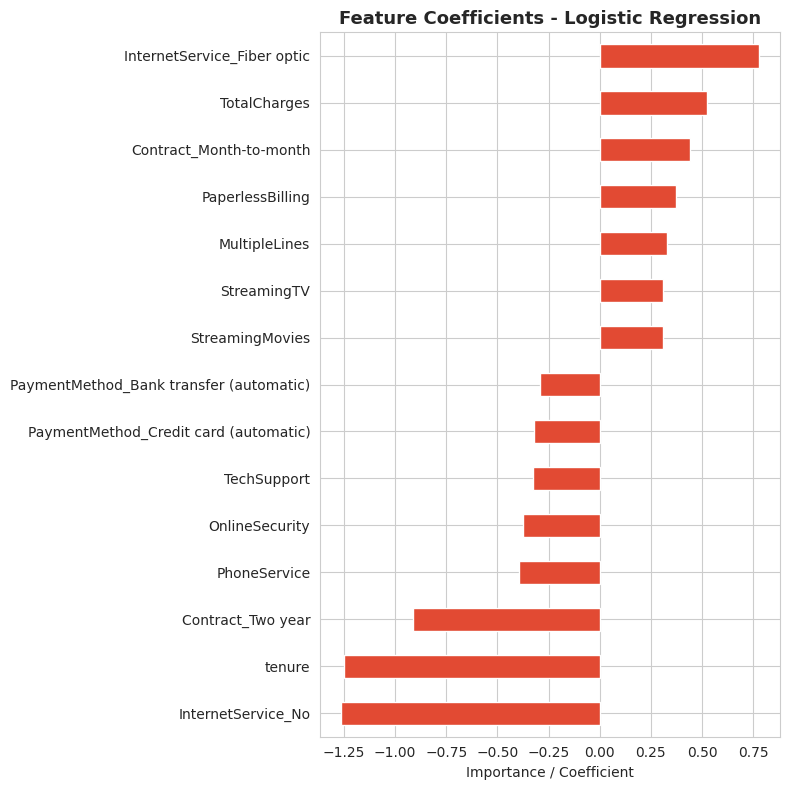

InternetService_No            -1.264727
tenure                        -1.247394
Contract_Two year             -0.914545
InternetService_Fiber optic    0.779203
TotalCharges                   0.523789
Contract_Month-to-month        0.441774
PhoneService                  -0.395453
OnlineSecurity                -0.376610
PaperlessBilling               0.371936
MultipleLines                  0.330193
dtype: float64


In [ ]:
if hasattr(final_model, 'feature_importances_'):
    fi = pd.Series(final_model.feature_importances_, index=final_X_test.columns).sort_values(ascending=False)
    title = f'Feature Importances - {best_model_name}'
elif hasattr(final_model, 'coef_'):
    fi = pd.Series(final_model.coef_[0], index=final_X_test.columns).sort_values(key=abs, ascending=False)
    title = f'Feature Coefficients - {best_model_name}'

plt.figure(figsize=(8, 8))
fi.head(15).sort_values().plot(kind='barh', color='#E24A33')
plt.title(title)
plt.xlabel('Importance / Coefficient')
plt.tight_layout()
plt.show()

print(fi.head(10))

---
## 3. Conclusion

**Key findings**

- Overall churn rate is roughly **26–27%**.
- **Contract type, tenure, and payment method** are the strongest churn drivers: month-to-month
  contracts, short tenure, and electronic-check payments are all associated with much higher churn.
- Demographic factors (gender in particular) have little predictive value; behavioral / account
  factors matter far more.
- The **tuned Random Forest** model provided the best balance of precision and recall, with a solid
  AUC, making it a reasonable candidate for a production churn-scoring model.

**Suggested next steps**

- Complete **Task 3 (Customer Segmentation)** to identify specific high-value, high-risk segments
  (e.g., high `MonthlyCharges` + month-to-month contract + short tenure) for targeted retention
  campaigns.
- Complete **Task 6 (Business Recommendations)** to translate these findings into concrete retention
  offers, and estimate their revenue impact using the model's churn probabilities.
- Consider addressing class imbalance (e.g., SMOTE or class weighting) and testing additional
  algorithms (e.g., Gradient Boosting/XGBoost) for further performance gains.